# Archived W&B loss curves

This notebook reads the three selected W&B ZIP archives committed under `wandb_runs/`. It uses no W&B credentials or network access. The plots separate total, prefix, and data loss where those metrics are available and show missing series explicitly.

In [1]:
"""Resolve the repository root, select the three archived run IDs, and set the 25-step rolling-mean window used later on noisy training curves."""

import json
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

RUN_IDS = ("cfvhydei", "ke71bap7", "9j4ies5w")
SMOOTHING_WINDOW = 25

working_directory = Path.cwd().resolve()
if (working_directory / "wandb_runs").is_dir():
    REPO_ROOT = working_directory
elif working_directory.name == "wandb_runs" and (working_directory.parent / "wandb_runs").is_dir():
    REPO_ROOT = working_directory.parent
else:
    raise RuntimeError("Run this notebook from the repository root or wandb_runs directory.")
ARCHIVE_ROOT = REPO_ROOT / "wandb_runs"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})

In [2]:
"""Load each selected ZIP from disk and define helpers that extract numeric (step, value) series from history.jsonl."""


def load_run_archive(run_id: str) -> dict[str, object]:
    """Load one uniquely identified run snapshot and its full history.

    Args:
        run_id: Immutable W&B run ID used as the archive filename stem.

    Returns:
        A dictionary with `archive_path` (repository-relative `Path`),
        `snapshot` (the complete `run.json` mapping), and `history` (a
        `DataFrame` containing every JSONL history row and metric column).
        Plotting cells consume `snapshot` for labels and `history` for data.

    Raises:
        RuntimeError: If no archive or more than one archive has the ID.
    """
    matching_paths = sorted(ARCHIVE_ROOT.glob(f"*/*/{run_id}.zip"))
    if len(matching_paths) != 1:
        raise RuntimeError(f"Expected one archive for {run_id}, found {matching_paths}")
    archive_path = matching_paths[0]
    with ZipFile(archive_path) as archive:
        snapshot = json.loads(archive.read("run.json"))
        history_rows = [json.loads(line) for line in archive.read("history.jsonl").splitlines()]
    return {
        "archive_path": archive_path.relative_to(REPO_ROOT),
        "snapshot": snapshot,
        "history": pd.DataFrame(history_rows),
    }


def metric_points(history: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Return numeric `(step, value)` observations for one metric.

    `train/global_step` is the preferred x-coordinate because W&B `_step`
    also advances for evaluation log events. `_step` is used only when the
    trainer-specific coordinate is absent. Duplicate steps retain the final
    logged value. Missing metrics return an empty two-column DataFrame.
    """
    step_column = "train/global_step" if "train/global_step" in history else "_step"
    if metric not in history or step_column not in history:
        return pd.DataFrame(columns=["step", "value"])
    points = history.loc[history[metric].notna(), [step_column, metric]].copy()
    points.columns = ["step", "value"]
    points["step"] = pd.to_numeric(points["step"], errors="coerce")
    points["value"] = pd.to_numeric(points["value"], errors="coerce")
    return points.dropna().drop_duplicates("step", keep="last").sort_values("step")


runs_by_id = {run_id: load_run_archive(run_id) for run_id in RUN_IDS}
assert all(not metric_points(run["history"], "train/loss").empty for run in runs_by_id.values())
assert not metric_points(runs_by_id["9j4ies5w"]["history"], "eval/loss").empty

In [6]:
summary_rows = []
for run_id, run in runs_by_id.items():
    snapshot = run["snapshot"]
    history = run["history"]
    metadata = snapshot.get("metadata") or {}
    memory = metadata.get("memory") or {}
    train_points = metric_points(history, "train/loss")
    eval_points = metric_points(history, "eval/loss")
    # print(memory.get("total", 0)) # 1082020048896
    # print(type(memory.get("total", 0))) # <class 'str'>
    summary_rows.append(
        {
            "run_id": run_id,
            "state": snapshot["state"],
            "history_rows": len(history),
            "train_loss_points": len(train_points),
            "eval_loss_points": len(eval_points),
            "last_train_step": int(train_points["step"].max()),
            "gpu_count": metadata.get("gpu_count"),
            "host_ram_gib": round(int(memory.get("total", 0)) / 2**30, 1),
            "archive": str(run["archive_path"]),
        }
    )

run_summary = pd.DataFrame(summary_rows).set_index("run_id")
display(run_summary)
print("No archive contains time-series RAM or VRAM utilization metrics; gpu_count and host_ram_gib are static hardware metadata.")

,state,history_rows,train_loss_points,eval_loss_points,last_train_step,gpu_count,host_ram_gib,archive
run_id,,,,,,,,
cfvhydei,crashed,685,685,0,685,4,1007.7,wandb_runs/4gate/deleteme/cfvhydei.zip
ke71bap7,killed,3061,3061,0,3061,4,1007.7,wandb_runs/4gate/deleteme/ke71bap7.zip
9j4ies5w,crashed,148,119,29,119,4,1007.7,wandb_runs/4gate/stego-kirchenbauer-prefix-kl/...


No archive contains time-series RAM or VRAM utilization metrics; gpu_count and host_ram_gib are static hardware metadata.


In [7]:
run_colors = dict(zip(RUN_IDS, plt.get_cmap("tab10").colors))


def plot_run_metric(axis, run_id: str, metric: str, smoothing_window: int = 1) -> int:
    """Plot one archived metric and return its observation count.

    Args:
        axis: Matplotlib axis receiving the line or lines.
        run_id: Key in `runs_by_id`, used for data, state, and color.
        metric: Exact `history.jsonl` column to plot.
        smoothing_window: Rolling-mean window. Values above one draw the raw
            observations faintly and label the smoothed curve.

    Returns:
        Number of numeric observations plotted; zero means the archive does
        not contain that series.
    """
    run = runs_by_id[run_id]
    points = metric_points(run["history"], metric)
    if points.empty:
        return 0
    state = run["snapshot"]["state"]
    color = run_colors[run_id]
    label = f"{run_id} ({state})"
    if smoothing_window > 1:
        axis.plot(points["step"], points["value"], color=color, alpha=0.18, linewidth=0.8)
        smoothed_values = points["value"].rolling(smoothing_window, min_periods=1).mean()
        axis.plot(points["step"], smoothed_values, color=color, linewidth=1.8, label=f"{label}, {smoothing_window}-step mean")
    else:
        axis.plot(points["step"], points["value"], color=color, linewidth=1.6, marker="o", markersize=3, label=label)
    return len(points)

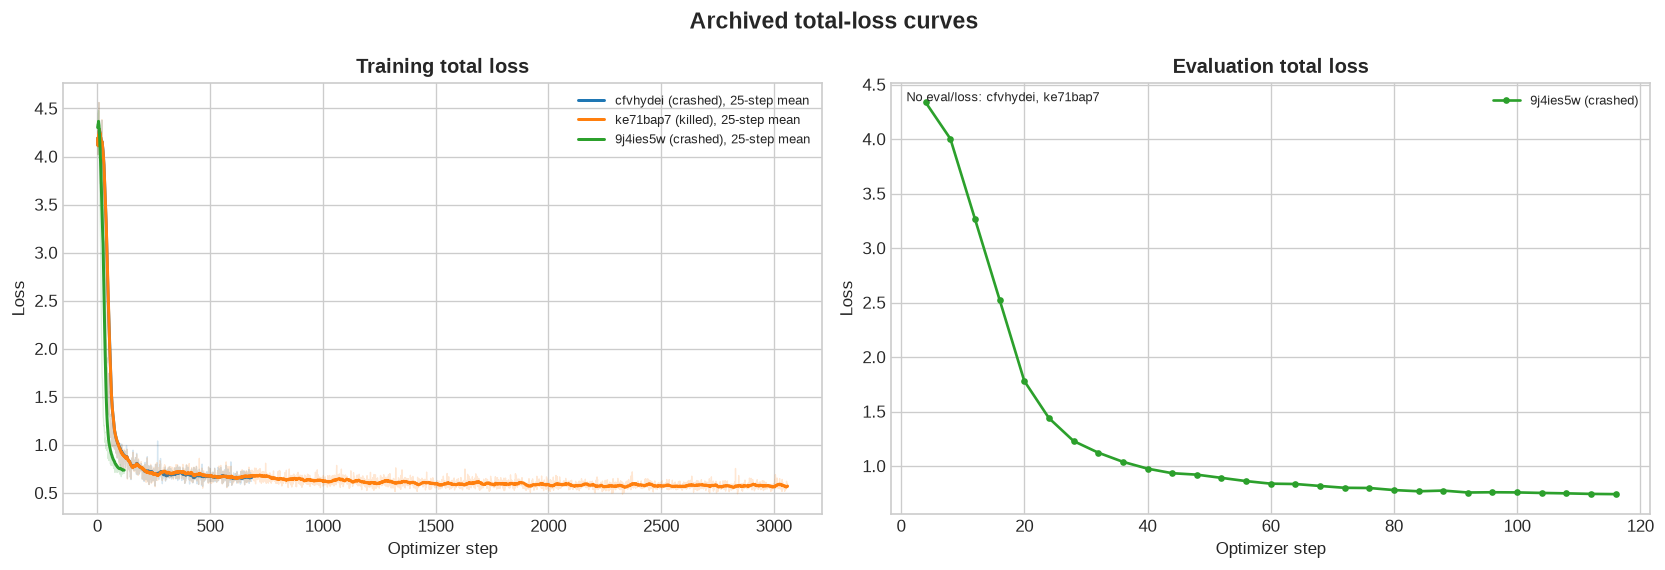

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for run_id in RUN_IDS:
    plot_run_metric(axes[0], run_id, "train/loss", SMOOTHING_WINDOW)
axes[0].set(title="Training total loss", xlabel="Optimizer step", ylabel="Loss")
axes[0].legend(fontsize=8)

missing_eval_runs = []
for run_id in RUN_IDS:
    if plot_run_metric(axes[1], run_id, "eval/loss") == 0:
        missing_eval_runs.append(run_id)
axes[1].set(title="Evaluation total loss", xlabel="Optimizer step", ylabel="Loss")
axes[1].legend(fontsize=8)
if missing_eval_runs:
    axes[1].text(0.02, 0.98, f"No eval/loss: {', '.join(missing_eval_runs)}", transform=axes[1].transAxes, va="top", fontsize=8)

figure.suptitle("Archived total-loss curves", fontsize=14, fontweight="bold")
figure.tight_layout()
plt.show()

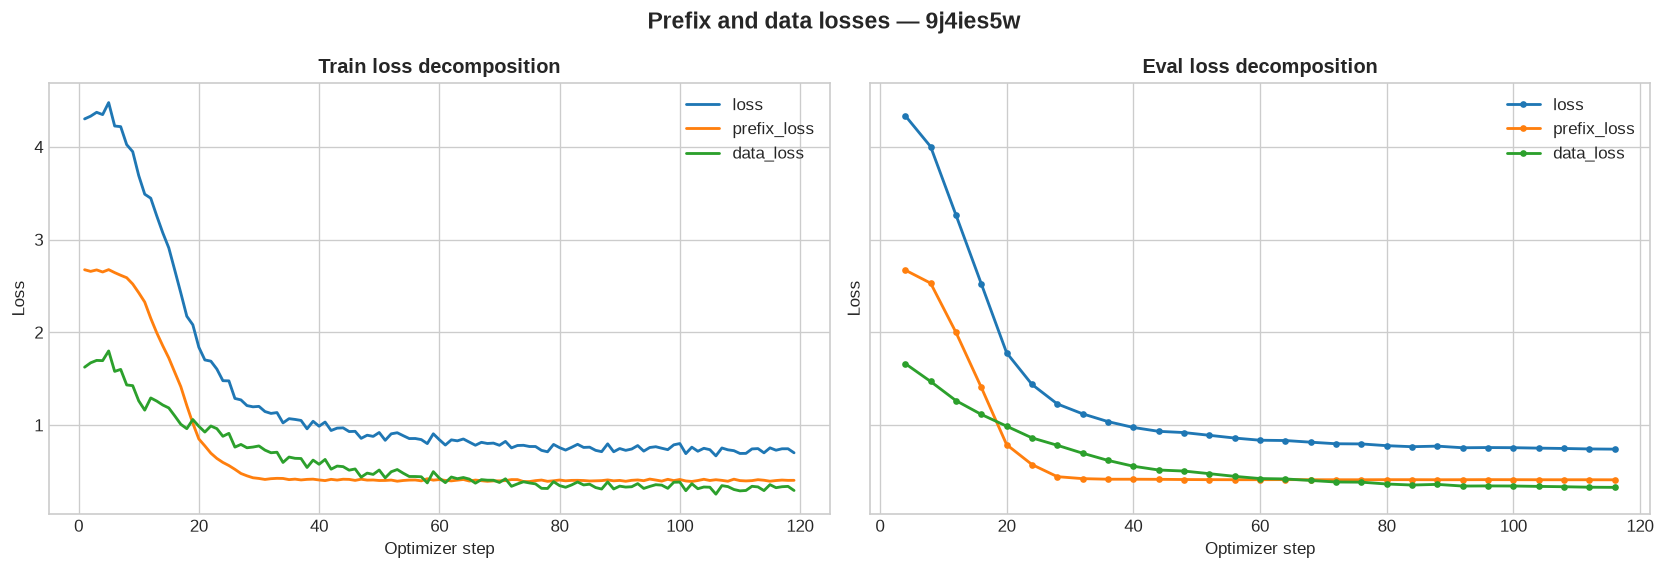

In [9]:
decomposed_run_id = "9j4ies5w"
component_colors = {"loss": "tab:blue", "prefix_loss": "tab:orange", "data_loss": "tab:green"}
figure, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for axis, mode in zip(axes, ("train", "eval")):
    for component in ("loss", "prefix_loss", "data_loss"):
        metric = f"{mode}/{component}"
        points = metric_points(runs_by_id[decomposed_run_id]["history"], metric)
        if points.empty:
            continue
        axis.plot(points["step"], points["value"], color=component_colors[component], linewidth=1.7, marker="o" if mode == "eval" else None, markersize=3, label=component)
    axis.set(title=f"{mode.title()} loss decomposition", xlabel="Optimizer step", ylabel="Loss")
    axis.legend()

figure.suptitle(f"Prefix and data losses — {decomposed_run_id}", fontsize=14, fontweight="bold")
figure.tight_layout()
plt.show()

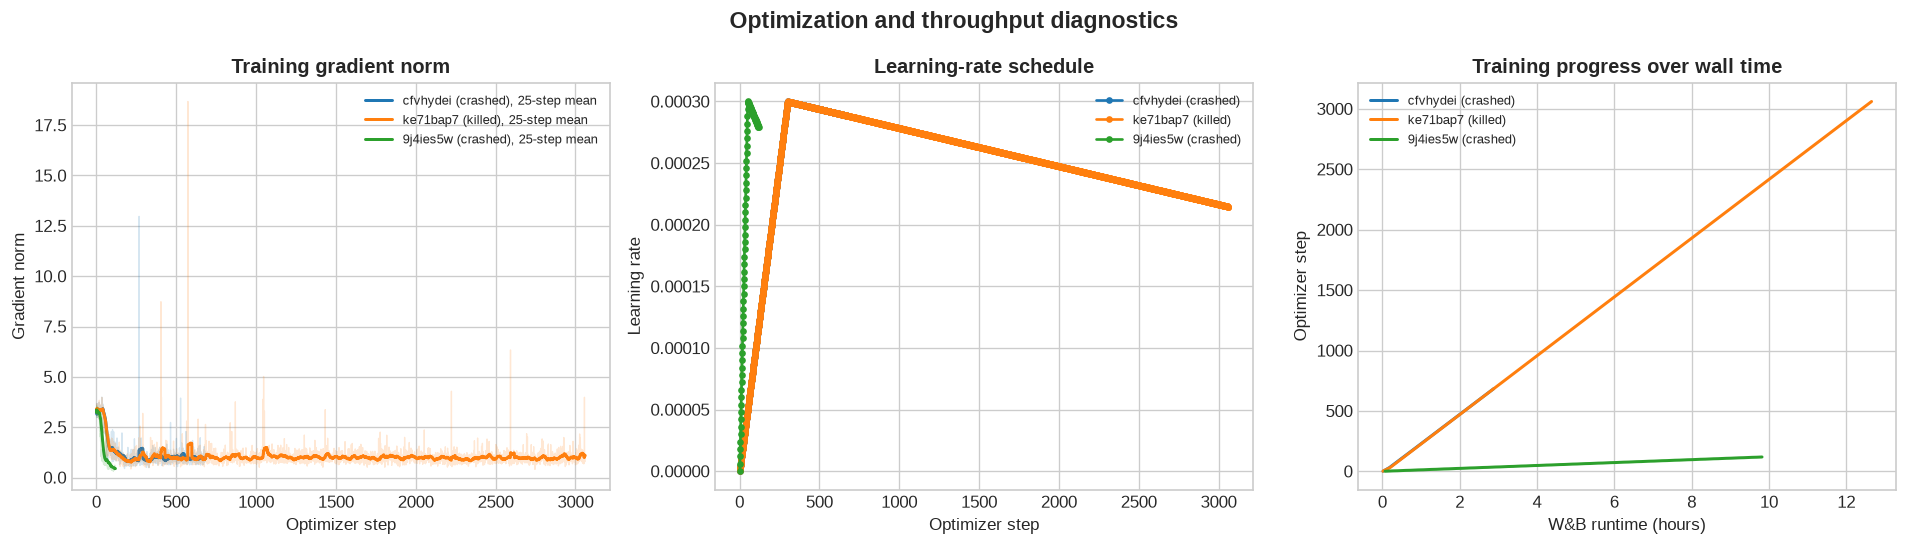

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for run_id in RUN_IDS:
    plot_run_metric(axes[0], run_id, "train/grad_norm", SMOOTHING_WINDOW)
    plot_run_metric(axes[1], run_id, "train/learning_rate")

    history = runs_by_id[run_id]["history"]
    if {"_runtime", "train/global_step", "train/loss"}.issubset(history.columns):
        training_rows = history.loc[history["train/loss"].notna(), ["_runtime", "train/global_step"]].dropna().drop_duplicates("train/global_step")
        axes[2].plot(training_rows["_runtime"] / 3600, training_rows["train/global_step"], color=run_colors[run_id], linewidth=1.8, label=f"{run_id} ({runs_by_id[run_id]['snapshot']['state']})")

axes[0].set(title="Training gradient norm", xlabel="Optimizer step", ylabel="Gradient norm")
axes[1].set(title="Learning-rate schedule", xlabel="Optimizer step", ylabel="Learning rate")
axes[2].set(title="Training progress over wall time", xlabel="W&B runtime (hours)", ylabel="Optimizer step")
for axis in axes:
    axis.legend(fontsize=8)
figure.suptitle("Optimization and throughput diagnostics", fontsize=14, fontweight="bold")
figure.tight_layout()
plt.show()

## Interpretation limits

The two `deleteme` runs contain training metrics but no evaluation metrics. Only `9j4ies5w` supports train-versus-eval comparisons and prefix/data decomposition. All three runs ended before their configured maximum step, and the archives do not contain time-series memory utilization. These curves support optimization diagnostics and early learning-curve comparisons, not a cross-model or cross-data scaling-law fit.